# NPE ACE Demo — Single Observation Fit

This notebook demonstrates fitting one ACE model using the trained NPE posterior (`results_ace_npe_se_proxy`).

**True parameters:** A = 0.5, C = 0.2, E = 0.3  
**Sample size:** N = 1000 twin pairs per zygosity

In [1]:
import sys
import json
import pickle
import warnings
from pathlib import Path

import joblib
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

warnings.filterwarnings('ignore')

SCRIPT_DIR = Path('.')
sys.path.insert(0, str(SCRIPT_DIR))

from train_ace_nn import ACEEmbeddingNet, ACE_PARAM_NAMES  # required for unpickling
from ACEnn import simulate_covariances

print('Imports OK')

Imports OK


In [2]:
# ── True parameters & sample size ──────────────────────────────────────────
A_TRUE = 0.5
C_TRUE = 0.2
E_TRUE = 0.3
N_PAIRS = 1000
SEED = 42
MODEL_DIR = SCRIPT_DIR / 'results_ace_npe_se_proxy'

np.random.seed(SEED)

# ── Simulate one observed covariance matrix ─────────────────────────────────
mz_cov_mat, dz_cov_mat = simulate_covariances(A_TRUE, C_TRUE, E_TRUE, N_pairs=N_PAIRS)

mz_var = float(mz_cov_mat[0, 0])
mz_cov = float(mz_cov_mat[0, 1])
dz_var = float(dz_cov_mat[0, 0])
dz_cov = float(dz_cov_mat[0, 1])
se_proxy = 1.0 / np.sqrt(N_PAIRS)

print(f'True:  A={A_TRUE:.2f}  C={C_TRUE:.2f}  E={E_TRUE:.2f}')
print(f'N pairs: {N_PAIRS}')
print(f'\nSimulated statistics:')
print(f'  mz_var = {mz_var:.4f}   (theory: {A_TRUE+C_TRUE+E_TRUE:.4f})')
print(f'  mz_cov = {mz_cov:.4f}   (theory: {A_TRUE+C_TRUE:.4f})')
print(f'  dz_var = {dz_var:.4f}   (theory: {A_TRUE+C_TRUE+E_TRUE:.4f})')
print(f'  dz_cov = {dz_cov:.4f}   (theory: {0.5*A_TRUE+C_TRUE:.4f})')
print(f'  se_proxy (1/√N) = {se_proxy:.6f}')

True:  A=0.50  C=0.20  E=0.30
N pairs: 1000

Simulated statistics:
  mz_var = 0.9423   (theory: 1.0000)
  mz_cov = 0.6315   (theory: 0.7000)
  dz_var = 1.0477   (theory: 1.0000)
  dz_cov = 0.4603   (theory: 0.4500)
  se_proxy (1/√N) = 0.031623


In [3]:
# ── Load trained posterior ───────────────────────────────────────────────────
with open(MODEL_DIR / 'config.json') as f:
    config = json.load(f)

feature_cols = config['feature_cols']
print(f'Model feature cols: {feature_cols}')

with open(MODEL_DIR / 'posterior.pkl', 'rb') as f:
    posterior = pickle.load(f)

scaler = joblib.load(MODEL_DIR / 'feature_scaler.pkl')

if hasattr(posterior, '_neural_net'):
    posterior._neural_net.eval()

print('Posterior loaded successfully.')

Model feature cols: ['mz_var', 'mz_cov', 'dz_var', 'dz_cov', 'se_proxy']
Posterior loaded successfully.


In [4]:
# ── Scale the observation and draw posterior samples ─────────────────────────
N_POSTERIOR = 5000

x_raw = np.array([mz_var, mz_cov, dz_var, dz_cov, se_proxy], dtype=np.float32).reshape(1, -1)
x_scaled = scaler.transform(x_raw).flatten()

x_tensor = torch.FloatTensor(x_scaled).unsqueeze(0)

with torch.no_grad():
    samples = posterior.sample(
        (N_POSTERIOR,), x=x_tensor,
        show_progress_bars=False,
        reject_outside_prior=False,
    )

samples_np = samples.numpy()  # (N_POSTERIOR, 3)

post_mean = samples_np.mean(axis=0)
post_std  = samples_np.std(axis=0)
post_med  = np.median(samples_np, axis=0)

print(f'Posterior draws: {N_POSTERIOR}')
print(f'\n{"":<6} {"True":>8} {"Mean":>8} {"Median":>8} {"SD":>8}')
print('-' * 44)
for i, p in enumerate(ACE_PARAM_NAMES):
    truth = [A_TRUE, C_TRUE, E_TRUE][i]
    print(f'{p:<6} {truth:>8.4f} {post_mean[i]:>8.4f} {post_med[i]:>8.4f} {post_std[i]:>8.4f}')

Posterior draws: 5000

           True     Mean   Median       SD
--------------------------------------------
A        0.5000   0.4565   0.4582   0.0746
C        0.2000   0.2112   0.2121   0.0650
E        0.3000   0.3312   0.3297   0.0300


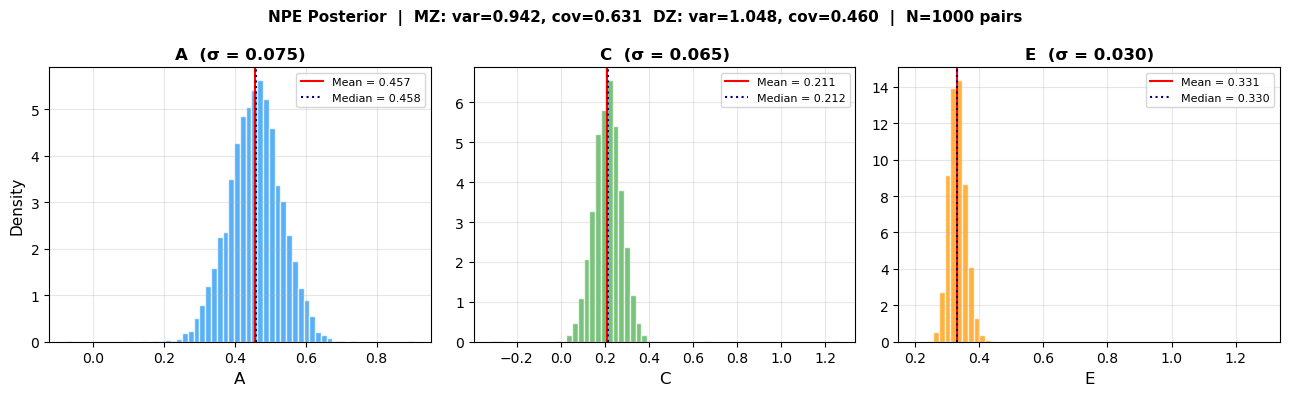

Saved → demo_posterior.png


In [7]:
# ── Visualise posterior distributions ───────────────────────────────────────
colors = ['#2196F3', '#4CAF50', '#FF9800']

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for i, (ax, param, color) in enumerate(zip(axes, ACE_PARAM_NAMES, colors)):
    ax.hist(samples_np[:, i], bins=60, color=color, alpha=0.75, density=True, edgecolor='white')
    ax.axvline(post_mean[i], color='red',   lw=1.5, linestyle='-',  label=f'Mean = {post_mean[i]:.3f}')
    ax.axvline(post_med[i],  color='navy',  lw=1.5, linestyle=':',  label=f'Median = {post_med[i]:.3f}')
    ax.set_xlabel(param, fontsize=12)
    ax.set_ylabel('Density' if i == 0 else '', fontsize=11)
    ax.set_title(f'{param}  (σ = {post_std[i]:.3f})', fontsize=12, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle(
    f'NPE Posterior  |  '
    f'MZ: var={mz_var:.3f}, cov={mz_cov:.3f}  '
    f'DZ: var={dz_var:.3f}, cov={dz_cov:.3f}  '
    f'|  N={N_PAIRS} pairs',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.savefig(SCRIPT_DIR / 'demo_posterior.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → demo_posterior.png')


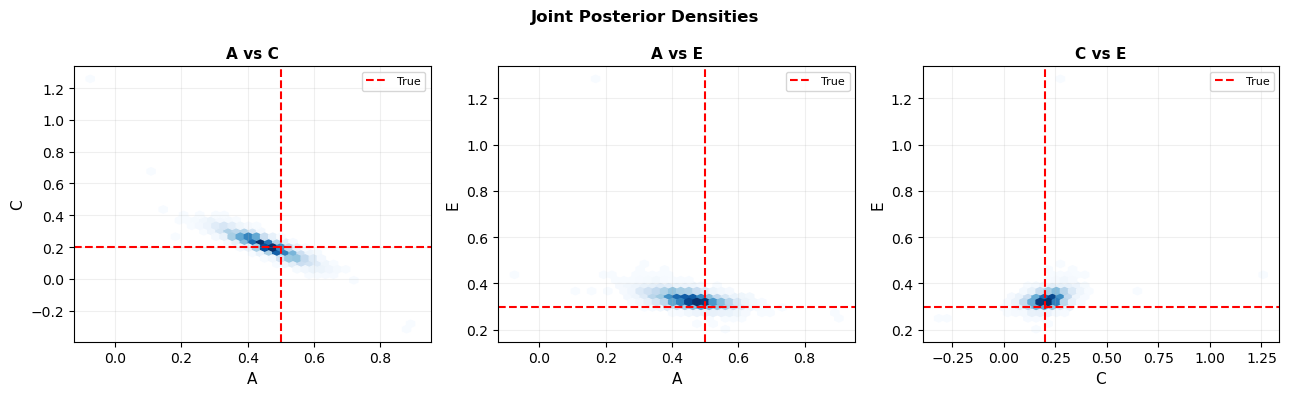

Saved → demo_joint_posterior.png


In [6]:
# ── 2-D joint posteriors (A vs C, A vs E, C vs E) ───────────────────────────
pairs = [('A', 'C', 0, 1), ('A', 'E', 0, 2), ('C', 'E', 1, 2)]

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (px_name, py_name, ix, iy) in zip(axes, pairs):
    ax.hexbin(samples_np[:, ix], samples_np[:, iy],
              gridsize=40, cmap='Blues', mincnt=1)
    ax.axvline([A_TRUE, A_TRUE, C_TRUE][pairs.index((px_name, py_name, ix, iy))],
               color='red', lw=1.5, linestyle='--')
    ax.axhline([C_TRUE, E_TRUE, E_TRUE][pairs.index((px_name, py_name, ix, iy))],
               color='red', lw=1.5, linestyle='--', label='True')
    ax.set_xlabel(px_name, fontsize=11)
    ax.set_ylabel(py_name, fontsize=11)
    ax.set_title(f'{px_name} vs {py_name}', fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.2)

fig.suptitle('Joint Posterior Densities', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(SCRIPT_DIR / 'demo_joint_posterior.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → demo_joint_posterior.png')